## Our goal is not to reduce the error. But, to increase the error slightly

In [1]:
# Import libraries

import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression,Lasso,Ridge,ElasticNet
from sklearn.model_selection import train_test_split

In [2]:
# load_dataset

data =fetch_california_housing()

data

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

In [9]:
X = pd.DataFrame(data.data,columns =data.feature_names)
y=data.target

# Taking only 350 Observation
X=X.head(350)
y=y[:350]

# Train Test Split
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.20,random_state=123,shuffle = True)


# Models
linear_model = LinearRegression()
ridge_model = Ridge(alpha=1.0)
lasso_model = Lasso(alpha=0.1)
elastic_model = ElasticNet(alpha=0.1,)

# Train models
linear_model.fit(X_train, y_train)
ridge_model.fit(X_train, y_train)
lasso_model.fit(X_train, y_train)
elastic_model.fit(X_train, y_train)

# Print Coefficients
print("Linear Regression Coeffficients")
print(linear_model.coef_)

print("Ridge Regression Coeffficients")
print(ridge_model.coef_)

print("Lasso Regression Coeffficients")
print(lasso_model.coef_)

print("Elastic Net Regression Coeffficients")
print(elastic_model.coef_)

Linear Regression Coeffficients
[ 3.11562118e-01 -5.73664081e-03 -1.41572292e-02 -1.00283573e+00
  8.98974036e-05 -5.68304571e-02  1.11950611e+01  1.81925913e+00]
Ridge Regression Coeffficients
[ 3.91956505e-01 -3.16654885e-03 -3.71028726e-02 -8.25969519e-01
  9.94790080e-05 -1.24957902e-01  1.33763185e+00 -1.15475391e+00]
Lasso Regression Coeffficients
[ 3.65639700e-01 -1.94216511e-03 -0.00000000e+00 -0.00000000e+00
  1.16068481e-04 -3.36210324e-02  0.00000000e+00 -0.00000000e+00]
Elastic Net Regression Coeffficients
[ 3.70673937e-01 -2.15159482e-03 -0.00000000e+00 -0.00000000e+00
  1.12729579e-04 -8.22909642e-02  0.00000000e+00 -0.00000000e+00]


      Feature  Coefficient
3   AveBedrms    -1.002836
5    AveOccup    -0.056830
2    AveRooms    -0.014157
1    HouseAge    -0.005737
4  Population     0.000090
0      MedInc     0.311562
7   Longitude     1.819259
6    Latitude    11.195061


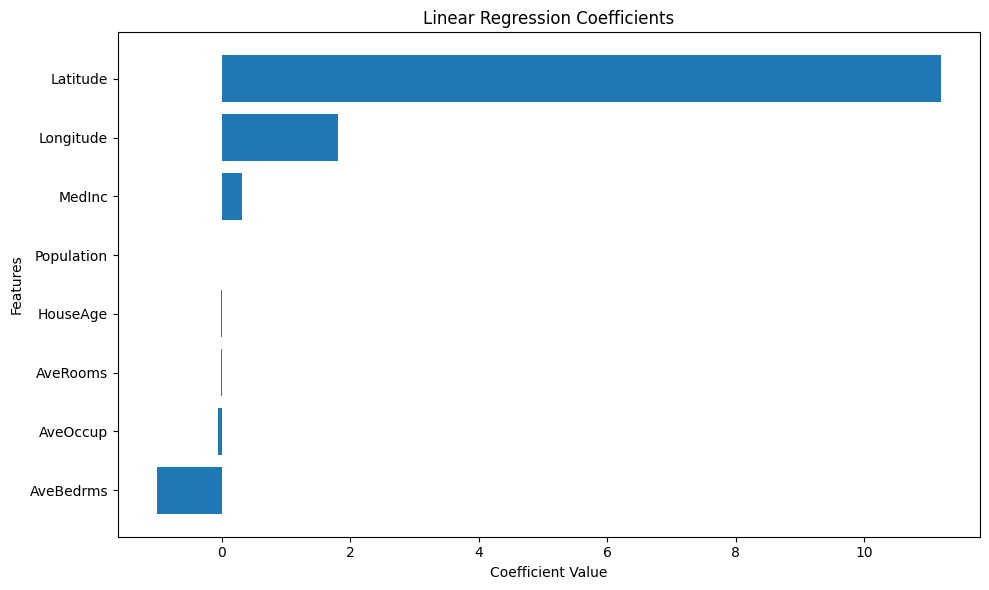

      Feature  Coefficient
7   Longitude    -1.154754
3   AveBedrms    -0.825970
5    AveOccup    -0.124958
2    AveRooms    -0.037103
1    HouseAge    -0.003167
4  Population     0.000099
0      MedInc     0.391957
6    Latitude     1.337632


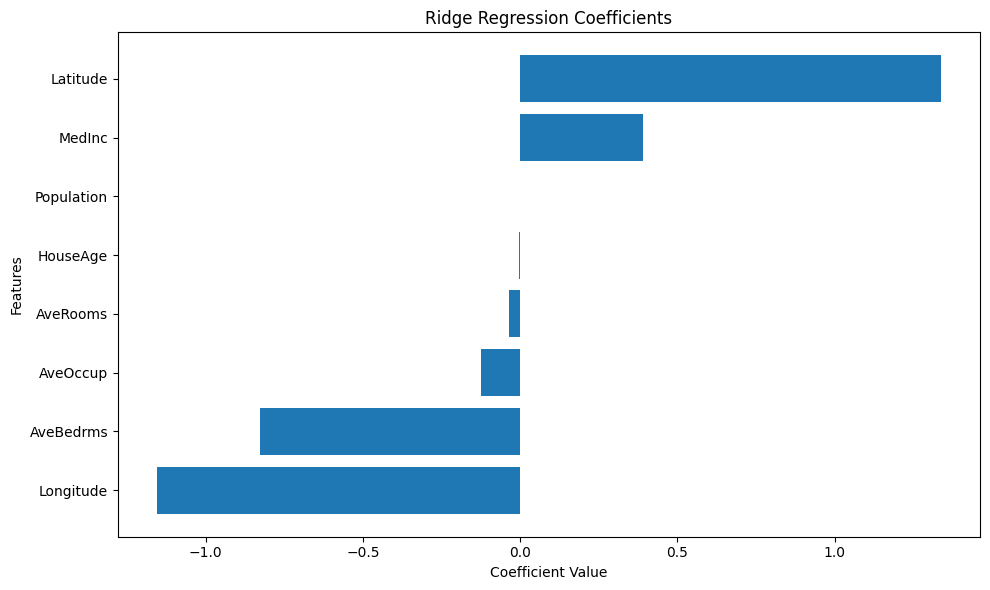

      Feature  Coefficient
5    AveOccup    -0.033621
1    HouseAge    -0.001942
3   AveBedrms    -0.000000
2    AveRooms    -0.000000
7   Longitude    -0.000000
6    Latitude     0.000000
4  Population     0.000116
0      MedInc     0.365640


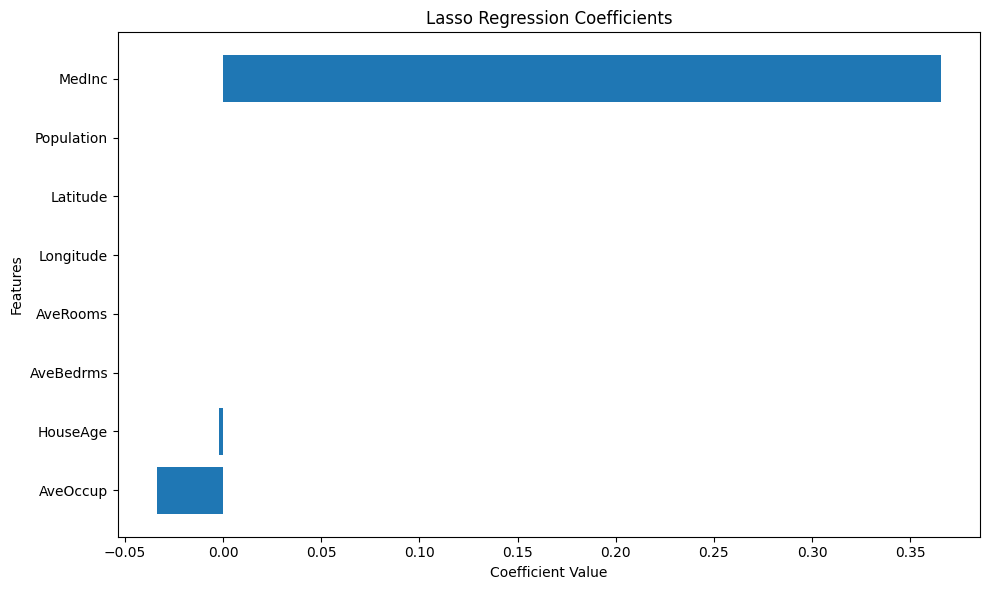

      Feature  Coefficient
5    AveOccup    -0.082291
1    HouseAge    -0.002152
3   AveBedrms    -0.000000
2    AveRooms    -0.000000
7   Longitude    -0.000000
6    Latitude     0.000000
4  Population     0.000113
0      MedInc     0.370674


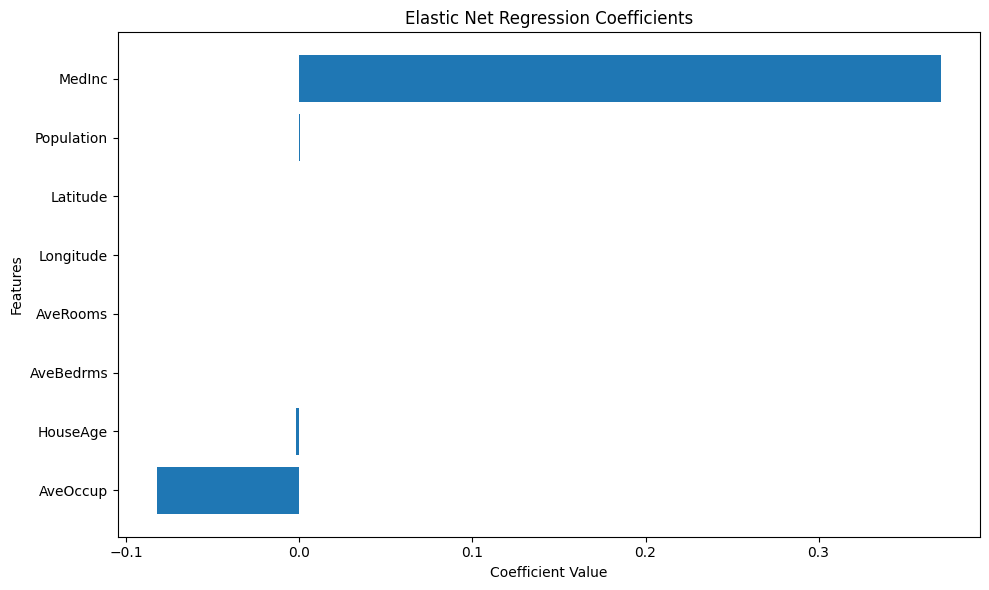

In [10]:
import matplotlib.pyplot as plt

# Function to plot coefficients
def plot_coefficients(model, feature_names, title):
    
    coef_df = pd.DataFrame({
        "Feature": feature_names,
        "Coefficient": model.coef_
    })

    coef_df = coef_df.sort_values(by="Coefficient")
    print(coef_df)
        
    plt.figure(figsize=(10,6))
    plt.barh(coef_df["Feature"], coef_df["Coefficient"])
    
    plt.title(title)
    plt.xlabel("Coefficient Value")
    plt.ylabel("Features")
    
    plt.tight_layout()
    plt.show()


# Linear Regression
plot_coefficients(
    linear_model,
    X.columns,
    "Linear Regression Coefficients"
)

# Ridge Regression
plot_coefficients(
    ridge_model,
    X.columns,
    "Ridge Regression Coefficients"
)

# Lasso Regression
plot_coefficients(
    lasso_model,
    X.columns,
    "Lasso Regression Coefficients"
)

# Elastic Net
plot_coefficients(
    elastic_model,
    X.columns,
    "Elastic Net Regression Coefficients"
)

In [11]:
from sklearn.metrics import mean_squared_error, r2_score

models = {
    "Linear": linear_model,
    "Ridge": ridge_model,
    "Lasso": lasso_model,
    "ElasticNet": elastic_model
}

for name, model in models.items():
    
    y_pred = model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(name)
    print("MSE:", mse)
    print("R2:", r2)
    print()

Linear
MSE: 0.18099579693537973
R2: 0.695162515603555

Ridge
MSE: 0.20468083477301122
R2: 0.655271603911081

Lasso
MSE: 0.23693083073344579
R2: 0.6009553832759449

ElasticNet
MSE: 0.220298733784796
R2: 0.6289675619005918



# VERY IMPORTANT POINT TO NOTE:

#### Regularized models may show slightly higher training cost, but they generalize better on unseen data.